In [4]:
import pandas as pd
import tensorflow as tf
import numpy as np
import gc
import time
import matplotlib.pyplot as plt
#from livelossplot.keras import PlotLossesCallback
from tensorflow.keras.callbacks import ReduceLROnPlateau
#from keras.models import load_model
import csv
from itertools import chain

### 设置GPU显存按需分配

In [5]:
#如果没有装GPU版本，这部分就不用写，但是如果不用GPU加速计算，使用CPU将会严重限制模型的训练速度
gpus = tf.config.experimental.list_physical_devices('GPU') 
if gpus:
  try:

    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:

    print(e)

1 Physical GPUs, 1 Logical GPUs


In [6]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
cpus = tf.config.experimental.list_physical_devices(device_type='CPU')
print(gpus, cpus)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [7]:
print(tf.__version__)

1.14.0


### 载入数据

In [8]:
data_train=pd.read_csv('F:/TensorFlow/xinjiang/traindata20230307.csv',header=0,encoding='utf_8')
data_train.info()
data_train.className.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 903 entries, 0 to 902
Columns: 295 entries, className to Y
dtypes: float64(17), int64(277), object(1)
memory usage: 2.0+ MB


array(['白茎绢蒿荒漠', '早熟禾草甸', '芦苇盐生草甸', '寸草苔草甸（1:100图，薹草、杂类草草甸）', '芦苇草甸',
       '羊茅草原', '盐生假木贼荒漠', '克氏针茅草原', '膜果麻黄荒漠', '含盐生半灌木的芦苇盐生草甸', '合头草荒漠',
       '针茅草原', '其它嵩草草甸', '其它薹草草甸', '紫花针茅草原', '早熟禾杂类草草甸', '芦苇盐生草甸（含盐生半灌木）',
       '盐生草荒漠', '木本猪毛菜荒漠', '蒿叶猪毛菜荒漠', '驼绒藜荒漠', '新疆银穗草草原', '蒿属荒漠', '小蓬荒漠',
       '戈壁藜荒漠', '沙生针茅荒漠草原', '麻黄荒漠', '梭梭荒漠', '短叶假木贼荒漠', '枇杷柴荒漠', '霸王荒漠',
       '含多枝柽柳的花花柴盐生草甸', '疏叶骆驼刺盐生草甸', '冷蒿荒漠草原', '柽柳灌丛', '多枝柽柳荒漠',
       '含多枝柽柳的芦苇盐生草甸', '花花柴盐生草甸', '裸地', '沙拐枣属荒漠', '猪毛菜属荒漠', '芨芨草草原',
       '旱蒿荒漠', '短花针茅荒漠草原', '镰芒针茅矮半灌木荒漠草原', '芨芨草草甸', '小针茅荒漠草原',
       '薹草、珠芽蓼高寒草甸', '高山嵩草高寒草甸', '草原苔草、杂类草草甸草原', '线叶嵩草草甸', '短花针茅典型草原',
       '杂类草高寒草甸', '高山绢蒿荒漠', '紫花针茅、新疆银穗草草原', '柽柳属荒漠', '绢蒿属荒漠',
       '昆仑针茅、高山绢蒿荒漠草原', '新疆银穗草、穗状寒生羊茅荒漠草原', '镰芒针茅荒漠草原', '人工草地',
       '早熟禾、羽衣草草甸', '鸭茅草甸', '羊茅、杂类草草甸草原', '锦鸡儿、镰芒针茅荒漠草原'], dtype=object)

In [9]:
pd.set_option('display.max_rows', None)
print(data_train['className'].value_counts())

芦苇草甸                      77
紫花针茅草原                    44
含多枝柽柳的芦苇盐生草甸              38
疏叶骆驼刺盐生草甸                 33
针茅草原                      33
驼绒藜荒漠                     33
枇杷柴荒漠                     29
芦苇盐生草甸                    27
盐生假木贼荒漠                   26
旱蒿荒漠                      26
梭梭荒漠                      25
线叶嵩草草甸                    22
高山绢蒿荒漠                    19
膜果麻黄荒漠                    19
白茎绢蒿荒漠                    18
其它薹草草甸                    18
其它嵩草草甸                    17
合头草荒漠                     16
戈壁藜荒漠                     15
花花柴盐生草甸                   14
短叶假木贼荒漠                   14
草原苔草、杂类草草甸草原              13
柽柳灌丛                      11
高山嵩草高寒草甸                  11
小针茅荒漠草原                   11
新疆银穗草草原                   11
新疆银穗草、穗状寒生羊茅荒漠草原          10
杂类草高寒草甸                   10
小蓬荒漠                      10
木本猪毛菜荒漠                   10
沙生针茅荒漠草原                  10
猪毛菜属荒漠                     9
霸王荒漠                       9
羊茅草原                       9
羊茅、杂类草草甸草原    

In [10]:
data_train.head()

,className,num,AET2020,AET2021,AET2101,AET2102,AET2103,AET2104,AET2105,AET2106,...,SR220922B7,SR220930B1,SR220930B2,SR220930B3,SR220930B4,SR220930B5,SR220930B6,SR220930B7,X,Y
0,白茎绢蒿荒漠,0,136.083333,127.250000,0,0,0,415,78,237,...,4177,2031,2721,944,1595,3356,3841,3139,88.152900,47.632500
1,白茎绢蒿荒漠,0,141.083333,134.750000,0,0,0,435,76,257,...,1903,1395,2392,725,1163,2806,2906,2116,87.721392,47.665344
2,白茎绢蒿荒漠,0,138.750000,132.083333,0,0,0,499,73,322,...,2619,1661,2579,863,1321,3027,3188,2565,87.613085,47.772503
3,早熟禾草甸,1,192.333333,168.166667,0,0,0,0,732,457,...,1970,1303,2367,658,1046,2951,2960,2075,88.290677,48.006682
4,芦苇盐生草甸,2,117.750000,111.000000,0,0,12,335,73,248,...,24,120,33,178,538,16,23,24,87.412301,47.507040


In [11]:
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_train))
# 用生成的乱的索引就能将其打乱了
data_all = data_train.iloc[index ,:]

### 类别数量

In [12]:
num_classes = data_train['num'].nunique()
print(num_classes)

65


### 不测试时使用全部数据训练

In [13]:
train_x = data_train.iloc[:,2:]
train_y = data_train.loc[:, ['num']] 

In [14]:
train_x.head()

,AET2020,AET2021,AET2101,AET2102,AET2103,AET2104,AET2105,AET2106,AET2107,AET2108,...,SR220922B7,SR220930B1,SR220930B2,SR220930B3,SR220930B4,SR220930B5,SR220930B6,SR220930B7,X,Y
0,136.083333,127.250000,0,0,0,415,78,237,132,428,...,4177,2031,2721,944,1595,3356,3841,3139,88.152900,47.632500
1,141.083333,134.750000,0,0,0,435,76,257,168,354,...,1903,1395,2392,725,1163,2806,2906,2116,87.721392,47.665344
2,138.750000,132.083333,0,0,0,499,73,322,219,425,...,2619,1661,2579,863,1321,3027,3188,2565,87.613085,47.772503
3,192.333333,168.166667,0,0,0,0,732,457,294,507,...,1970,1303,2367,658,1046,2951,2960,2075,88.290677,48.006682
4,117.750000,111.000000,0,0,12,335,73,248,162,254,...,24,120,33,178,538,16,23,24,87.412301,47.507040


### 顺序编码转独热编码

In [15]:
train_y = tf.keras.utils.to_categorical(train_y)

In [16]:
pd.set_option('display.max_columns', None)
train_y

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [17]:
train_y.shape[1]

65

In [18]:
dim_num = train_x.shape[1]
print(dim_num)

293


### 定义损失函数为Focal Loss

In [19]:
def multi_category_focal_loss2(gamma=2., alpha=.25):
    """
    focal loss for multi category of multi label problem
    适用于多分类或多标签问题的focal loss
    alpha控制真值y_true为1/0时的权重
        1的权重为alpha, 0的权重为1-alpha
    当你的模型欠拟合，学习存在困难时，可以尝试适用本函数作为loss
    当模型过于激进(无论何时总是倾向于预测出1),尝试将alpha调小
    当模型过于惰性(无论何时总是倾向于预测出0,或是某一个固定的常数,说明没有学到有效特征)
        尝试将alpha调大,鼓励模型进行预测出1。
    Usage:
     model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=["accuracy"], optimizer='adam')
    """
    epsilon = 1.e-7
    gamma = float(gamma)
    alpha = tf.constant(alpha, dtype=tf.float32)

    def multi_category_focal_loss2_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    
        alpha_t = y_true*alpha + (tf.ones_like(y_true)-y_true)*(1-alpha)
        y_t = tf.multiply(y_true, y_pred) + tf.multiply(1-y_true, 1-y_pred)
        y_t = tf.clip_by_value(y_t, epsilon, 1. - epsilon)#这句是后加的
        ce = -tf.math.log(y_t)
        weight = tf.math.pow(tf.subtract(1., y_t), gamma)
        fl = tf.multiply(tf.multiply(weight, ce), alpha_t)
        loss = tf.reduce_mean(fl)
        return loss
    return multi_category_focal_loss2_fixed

### 模型构建

In [20]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(8192,input_dim=dim_num))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(4096,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(2048,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(1024,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(512,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(256,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(64,activation='relu'))
#model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(32,activation='relu'))#注：如果后面再加16，8，16，32这样的全连结层，精度反而会变低
model.add(tf.keras.layers.Dropout(rate=0.5))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))
# 让学习率自动变化
reduce_lr = ReduceLROnPlateau(monitor='loss',factor=0.01, patience=20, mode='auto')
model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=['acc'], optimizer='adam')#adam优化
#顺序编码用loss='sparse_categorical_crossentropy'
#独热编码用loss='categorical_crossentropy'
model.summary()

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 8192)              2408448   
_________________________________________________________________
batch_normalization (BatchNo (None, 8192)              32768     
_________________________________________________________________
dense_1 (Dense)              (None, 4096)              33558528  
_________________________________________________________________
batch_normalization_1 (Batch (None, 4096)              16384     
_________________________________________________________________
dense_2 (Dense)              (None, 2048)              8390656   
_________________________________________________________________
batch_normalization_2 (Batch (None, 2048)              8192      
____

### 开始训练

In [21]:
e = 400
start = time.perf_counter()#time.process_time()测的时间偏长
history = model.fit(train_x,train_y, epochs=e,batch_size=64,verbose=1,callbacks=[reduce_lr])#batch_size=16,validation_data=(validation_x,validation_y)
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Epoch 1/400
903/903 [==============================] - 1s 2ms/sample - loss: 0.0190 - acc: 0.0388
Epoch 2/400
903/903 [==============================] - 0s 249us/sample - loss: 0.0157 - acc: 0.1130
Epoch 3/400
903/903 [==============================] - 0s 248us/sample - loss: 0.0149 - acc: 0.1207
Epoch 4/400
903/903 [==============================] - 0s 246us/sample - loss: 0.0140 - acc: 0.1451
Epoch 5/400
903/903 [==============================] - 0s 248us/sample - loss: 0.0135 - acc: 0.1262
Epoch 6/400
903/903 [==============================] - 0s 247us/sample - loss: 0.0133 - acc: 0.1340
Epoch 7/400
903/903 [==============================] - 0s 249us/sample - loss: 0.0129 - acc: 0.1440
Epoch 8/400
903/903 [==============================] - 0s 256us/sample - loss: 0.0121 - acc: 0.1805
Epoch 9/400
903/903 [==============================] - 0s 254us/sample - loss: 0.0120 - acc: 0.1440
Epoch 10

903/903 [==============================] - 0s 248us/sample - loss: 0.0049 - acc: 0.5260
Epoch 79/400
903/903 [==============================] - 0s 249us/sample - loss: 0.0049 - acc: 0.5260
Epoch 80/400
903/903 [==============================] - 0s 249us/sample - loss: 0.0045 - acc: 0.5471
Epoch 81/400
903/903 [==============================] - 0s 251us/sample - loss: 0.0043 - acc: 0.5836
Epoch 82/400
903/903 [==============================] - 0s 256us/sample - loss: 0.0041 - acc: 0.5980
Epoch 83/400
903/903 [==============================] - 0s 250us/sample - loss: 0.0042 - acc: 0.5958
Epoch 84/400
903/903 [==============================] - 0s 249us/sample - loss: 0.0038 - acc: 0.6135
Epoch 85/400
903/903 [==============================] - 0s 253us/sample - loss: 0.0039 - acc: 0.6268
Epoch 86/400
903/903 [==============================] - 0s 251us/sample - loss: 0.0047 - acc: 0.5770
Epoch 87/400
903/903 [==============================] - 0s 254us/sample - loss: 0.0048 - acc: 0.5471
Epo

903/903 [==============================] - 0s 248us/sample - loss: 0.0038 - acc: 0.6578
Epoch 159/400
903/903 [==============================] - 0s 245us/sample - loss: 0.0033 - acc: 0.6800
Epoch 160/400
903/903 [==============================] - 0s 247us/sample - loss: 0.0032 - acc: 0.7065
Epoch 161/400
903/903 [==============================] - 0s 251us/sample - loss: 0.0031 - acc: 0.6977
Epoch 162/400
903/903 [==============================] - 0s 250us/sample - loss: 0.0031 - acc: 0.6899
Epoch 163/400
903/903 [==============================] - 0s 250us/sample - loss: 0.0028 - acc: 0.7143
Epoch 164/400
903/903 [==============================] - 0s 248us/sample - loss: 0.0032 - acc: 0.6833
Epoch 165/400
903/903 [==============================] - 0s 252us/sample - loss: 0.0028 - acc: 0.7409
Epoch 166/400
903/903 [==============================] - 0s 245us/sample - loss: 0.0028 - acc: 0.7165
Epoch 167/400
903/903 [==============================] - 0s 249us/sample - loss: 0.0032 - acc: 0

903/903 [==============================] - 0s 247us/sample - loss: 0.0016 - acc: 0.8527
Epoch 239/400
903/903 [==============================] - 0s 246us/sample - loss: 0.0016 - acc: 0.8383
Epoch 240/400
903/903 [==============================] - 0s 248us/sample - loss: 0.0015 - acc: 0.8527
Epoch 241/400
903/903 [==============================] - 0s 244us/sample - loss: 0.0015 - acc: 0.8527
Epoch 242/400
903/903 [==============================] - 0s 245us/sample - loss: 0.0015 - acc: 0.8549
Epoch 243/400
903/903 [==============================] - 0s 243us/sample - loss: 0.0016 - acc: 0.8372
Epoch 244/400
903/903 [==============================] - 0s 244us/sample - loss: 0.0015 - acc: 0.8361
Epoch 245/400
903/903 [==============================] - 0s 244us/sample - loss: 0.0016 - acc: 0.8461
Epoch 246/400
903/903 [==============================] - 0s 246us/sample - loss: 0.0015 - acc: 0.8549
Epoch 247/400
903/903 [==============================] - 0s 244us/sample - loss: 0.0016 - acc: 0

903/903 [==============================] - 0s 246us/sample - loss: 0.0015 - acc: 0.8571
Epoch 319/400
903/903 [==============================] - 0s 249us/sample - loss: 0.0015 - acc: 0.8416
Epoch 320/400
903/903 [==============================] - 0s 245us/sample - loss: 0.0016 - acc: 0.8328
Epoch 321/400
903/903 [==============================] - 0s 246us/sample - loss: 0.0016 - acc: 0.8483
Epoch 322/400
903/903 [==============================] - 0s 248us/sample - loss: 0.0017 - acc: 0.8217
Epoch 323/400
903/903 [==============================] - 0s 255us/sample - loss: 0.0014 - acc: 0.8527
Epoch 324/400
903/903 [==============================] - 0s 252us/sample - loss: 0.0016 - acc: 0.8405
Epoch 325/400
903/903 [==============================] - 0s 246us/sample - loss: 0.0016 - acc: 0.8494
Epoch 326/400
903/903 [==============================] - 0s 244us/sample - loss: 0.0016 - acc: 0.8306
Epoch 327/400
903/903 [==============================] - 0s 247us/sample - loss: 0.0016 - acc: 0

903/903 [==============================] - 0s 245us/sample - loss: 0.0016 - acc: 0.8516
Epoch 399/400
903/903 [==============================] - 0s 242us/sample - loss: 0.0015 - acc: 0.8472
Epoch 400/400
903/903 [==============================] - 0s 246us/sample - loss: 0.0016 - acc: 0.8461
用时：00:01:34


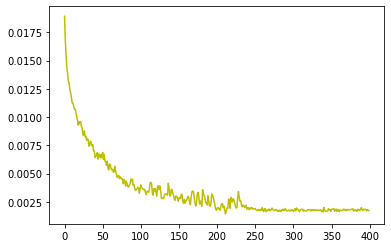

In [277]:
plt.plot(range(400),history.history.get('loss'),color =  'y')

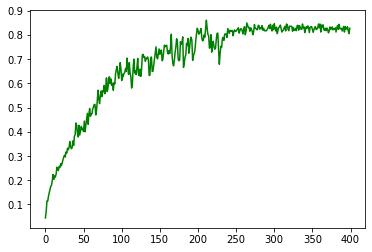

In [278]:
plt.plot(range(400),history.history.get('acc'),color =  'g')

### 各类别准确率

In [285]:
test_y = list(chain.from_iterable(test_y))
test_r = list(chain.from_iterable(test_r))

def count_nums(true_labels, num_classes):
    initial_value = 0
    list_length = num_classes
    list_data = [ initial_value for i in range(list_length)]
    for i in range(0, num_classes):
        list_data[i] = true_labels.count(i)
    return list_data

def accuracy(confusion_matrix, true_labels, num_classes):
    # 各个类别的测试样本的个数
    list_data = count_nums(true_labels, num_classes)
 
    # 各个类别正确分类的个数
    initial_value = 0
    list_length = num_classes
    true_pred = [ initial_value for i in range(list_length)]
    for i in range(0,num_classes):
        true_pred[i] = confusion_matrix[i][i]
 
    # 计算各个样本被正确分类的正确率
    classveg = []
    acc = []
    for i in range(0, num_classes):
        classveg.append(0)
        acc.append(0)
 
    for i in range(0,num_classes):
        classveg[i] = i
        acc[i] = float(true_pred[i] / list_data[i])
    
    z = pd.DataFrame(list(zip(classveg,acc,list_data)), columns=['class_code', 'acc','count'])
    return z

op = tf.math.confusion_matrix(test_y, test_r)

acc = accuracy(op, test_y, num_classes)
print(acc)

NameError: name 'test_y' is not defined

### 出结果

In [280]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/xinjiang/testresult20230309_1.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('F:/TensorFlow/xinjiang/a-y_split_1/testdata20230309_1.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 6s 57us/sample
1
100000/100000 [==============================] - 5s 53us/sample
2
100000/100000 [==============================] - 5s 53us/sample
3
100000/100000 [==============================] - 5s 54us/sample
4
100000/100000 [==============================] - 5s 54us/sample
5
100000/100000 [==============================] - 5s 54us/sample
6
100000/100000 [==============================] - 5s 54us/sample
7
100000/100000 [==============================] - 5s 54us/sample
8
100000/100000 [==============================] - 5s 53us/sample
9
100000/100000 [==============================] - 5s 54us/sample
10
100000/100000 [==============================] - 5s 52us/sample
11
100000/100000 [==============================] - 6s 56us/sample
12
100000/100000 [==============================] - 5s 55us/sample
13
100000/100000 [==============================] - 5s 55us/sample
14
100000/100000 [==============================] - 5s 54us/sample
15
10

In [281]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/xinjiang/testresult20230309_2.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('F:/TensorFlow/xinjiang/a-y_split_1/testdata20230309_2.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 5s 50us/sample
1
100000/100000 [==============================] - 5s 50us/sample
2
100000/100000 [==============================] - 5s 52us/sample
3
100000/100000 [==============================] - 5s 51us/sample
4
100000/100000 [==============================] - 6s 57us/sample
5
100000/100000 [==============================] - 6s 57us/sample
6
100000/100000 [==============================] - 5s 52us/sample
7
100000/100000 [==============================] - 5s 52us/sample
8
100000/100000 [==============================] - 5s 52us/sample
9
100000/100000 [==============================] - 5s 52us/sample
10
100000/100000 [==============================] - 5s 53us/sample
11
100000/100000 [==============================] - 5s 52us/sample
12
100000/100000 [==============================] - 12s 119us/sample
13
100000/100000 [==============================] - 102s 1ms/sample
14
100000/100000 [==============================] - 5s 51us/sample
15

In [282]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/xinjiang/testresult20230309_3.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('F:/TensorFlow/xinjiang/a-y_split_1/testdata20230309_3.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 5s 50us/sample
1
100000/100000 [==============================] - 5s 51us/sample
2
100000/100000 [==============================] - 5s 52us/sample
3
100000/100000 [==============================] - 5s 51us/sample
4
100000/100000 [==============================] - 5s 52us/sample
5
100000/100000 [==============================] - 5s 50us/sample
6
100000/100000 [==============================] - 5s 50us/sample
7
100000/100000 [==============================] - 5s 50us/sample
8
100000/100000 [==============================] - 5s 50us/sample
9
100000/100000 [==============================] - 5s 51us/sample
10
100000/100000 [==============================] - 5s 49us/sample
11
100000/100000 [==============================] - 5s 51us/sample
12
100000/100000 [==============================] - 5s 51us/sample
13
100000/100000 [==============================] - 5s 53us/sample
14
100000/100000 [==============================] - 5s 50us/sample
15
10

In [283]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/xinjiang/testresult20230309_4.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('F:/TensorFlow/xinjiang/a-y_split_1/testdata20230309_4.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 12s 117us/sample
1
100000/100000 [==============================] - 5s 52us/sample
2
100000/100000 [==============================] - 5s 52us/sample
3
100000/100000 [==============================] - 5s 52us/sample
4
100000/100000 [==============================] - 5s 50us/sample
5
100000/100000 [==============================] - 5s 51us/sample
6
100000/100000 [==============================] - 5s 52us/sample
7
100000/100000 [==============================] - 5s 50us/sample
8
100000/100000 [==============================] - 5s 51us/sample
9
100000/100000 [==============================] - 5s 51us/sample
10
100000/100000 [==============================] - 5s 51us/sample
11
100000/100000 [==============================] - 5s 52us/sample
12
100000/100000 [==============================] - 5s 52us/sample
13
100000/100000 [==============================] - 5s 51us/sample
14
100000/100000 [==============================] - 5s 51us/sample
15


In [284]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/xinjiang/testresult20230309_5.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('F:/TensorFlow/xinjiang/a-y_split_1/testdata20230309_5.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 5s 50us/sample
1
100000/100000 [==============================] - 5s 50us/sample
2
100000/100000 [==============================] - 5s 51us/sample
3
100000/100000 [==============================] - 5s 50us/sample
4
100000/100000 [==============================] - 5s 51us/sample
5
100000/100000 [==============================] - 5s 51us/sample
6
100000/100000 [==============================] - 5s 51us/sample
7
100000/100000 [==============================] - 5s 50us/sample
8
100000/100000 [==============================] - 5s 50us/sample
9
100000/100000 [==============================] - 5s 51us/sample
10
100000/100000 [==============================] - 5s 50us/sample
11
100000/100000 [==============================] - 5s 50us/sample
12
100000/100000 [==============================] - 5s 51us/sample
13
100000/100000 [==============================] - 5s 51us/sample
14
100000/100000 [==============================] - 5s 51us/sample
15
10